In [3]:
import pandas as pd
df = pd.read_parquet('../data/model_data.parquet')

x_cols = [c for c in df.columns if c.startswith("x")]
cond_cols = [c for c in df.columns if c.startswith("con")]

# fill missing values in cond columns with forward fill
# backward fill is needed for the first rows if they are missing (that is lookfowarding but very few rows are missing in the beginning after forward fill)
df["cond2"] = df["cond2"].ffill()
df["cond2"] = df["cond2"].bfill()

df["cond3"] = df["cond3"].ffill()
df["cond3"] = df["cond3"].bfill()

In [ ]:
from xml.parsers.expat import model

import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import List, Optional, Dict
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.cluster import KMeans


# --------------------------------------------------
# Helpers
# --------------------------------------------------

def get_year_index(s: pd.Series) -> pd.Series:
    return pd.to_datetime(s).dt.to_period("Y")


def fit_clip_and_scale_cond(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    cond_cols: List[str],
    q_low: float = 0.01,
    q_high: float = 0.99,
    final_clip: float = 5.0,
) -> tuple[np.ndarray, np.ndarray]:
    C_train = train_df[cond_cols].to_numpy(dtype=float)
    C_test = test_df[cond_cols].to_numpy(dtype=float)

    lower = np.quantile(C_train, q_low, axis=0)
    upper = np.quantile(C_train, q_high, axis=0)

    C_train = np.clip(C_train, lower, upper)
    C_test = np.clip(C_test, lower, upper)

    mean = C_train.mean(axis=0)
    std = C_train.std(axis=0)
    std = np.where(std < 1e-12, 1.0, std)

    C_train = (C_train - mean) / std
    C_test = (C_test - mean) / std

    C_train = np.clip(C_train, -final_clip, final_clip)
    C_test = np.clip(C_test, -final_clip, final_clip)

    return C_train, C_test


# --------------------------------------------------
# Window schedule
# --------------------------------------------------

@dataclass
class WindowSpec:
    mode: str              # "rolling" or "expanding"
    train_years: int = 4   # used for rolling
    min_train_years: int = 4


def build_yearly_schedule(
    df: pd.DataFrame,
    date_col: str,
    window_spec: WindowSpec,
) -> List[Dict]:
    tmp = df[[date_col]].copy()
    tmp[date_col] = pd.to_datetime(tmp[date_col])
    years = np.array(sorted(tmp[date_col].dt.to_period("Y").unique()))

    schedule = []
    for i in range(len(years) - 1):
        pred_year = years[i + 1]

        if window_spec.mode == "rolling":
            start_idx = i - window_spec.train_years + 1
            if start_idx < 0:
                continue
            train_years = years[start_idx:i + 1]

        elif window_spec.mode == "expanding":
            if i + 1 < window_spec.min_train_years:
                continue
            train_years = years[:i + 1]

        else:
            raise ValueError("window_spec.mode must be 'rolling' or 'expanding'")

        schedule.append({
            "train_years": train_years,
            "pred_year": pred_year,
        })

    return schedule


# --------------------------------------------------
# MoE
# --------------------------------------------------

class LogisticGateRidgeMoE:
    def __init__(
        self,
        n_experts: int = 3,
        ridge_alpha: float = 1.0,
        gate_C: float = 1.0,
        n_em_iters: int = 10,
        tau: Optional[float] = None,
        random_state: int = 0,
    ):
        self.n_experts = n_experts
        self.ridge_alpha = ridge_alpha
        self.gate_C = gate_C
        self.n_em_iters = n_em_iters
        self.tau = tau
        self.random_state = random_state

        self.experts = None
        self.gate = None

    def _init_models(self, X: np.ndarray, C: np.ndarray, y: np.ndarray):
        labels = KMeans(
            n_clusters=self.n_experts,
            n_init=20,
            random_state=self.random_state,
        ).fit_predict(C)

        self.experts = []
        for k in range(self.n_experts):
            mask = labels == k
            if mask.sum() < max(20, X.shape[1]):
                mask = np.ones(len(y), dtype=bool)

            n_eff = mask.sum()
            model = Ridge(alpha=self.ridge_alpha*n_eff, fit_intercept=False)
            model.fit(X[mask], y[mask])
            self.experts.append(model)

        self.gate = LogisticRegression(
            C=self.gate_C,
            multi_class="multinomial",
            solver="lbfgs",
            max_iter=1000,
            random_state=self.random_state,
        )
        self.gate.fit(C, labels)

    def _expert_preds(self, X: np.ndarray) -> np.ndarray:
        return np.column_stack([m.predict(X) for m in self.experts])

    def _responsibilities(
        self,
        y: np.ndarray,
        expert_preds: np.ndarray,
        gate_probs: np.ndarray,
    ) -> np.ndarray:
        sq_err = (y[:, None] - expert_preds) ** 2

        tau = self.tau
        if tau is None:
            tau = np.var(y)
            if tau < 1e-12:
                tau = 1.0

        likelihood = np.exp(-sq_err / tau)
        unnorm = gate_probs * likelihood
        denom = np.clip(unnorm.sum(axis=1, keepdims=True), 1e-12, None)
        return unnorm / denom

    def fit(self, X: np.ndarray, C: np.ndarray, y: np.ndarray):
        self._init_models(X, C, y)

        for _ in range(self.n_em_iters):
            expert_preds = self._expert_preds(X)
            gate_probs = self.gate.predict_proba(C)
            resp = self._responsibilities(y, expert_preds, gate_probs)

            new_experts = []
            for k in range(self.n_experts):
                n_eff = resp[:, k].sum()
                m = Ridge(alpha=self.ridge_alpha*n_eff, fit_intercept=False)
                m.fit(X, y, sample_weight=resp[:, k])
                new_experts.append(m)
            self.experts = new_experts

            labels = resp.argmax(axis=1)
            self.gate = LogisticRegression(
                C=self.gate_C,
                multi_class="multinomial",
                solver="lbfgs",
                max_iter=1000,
                random_state=self.random_state,
            )
            self.gate.fit(C, labels)

        return self

    def predict_components(self, X: np.ndarray, C: np.ndarray):
        expert_preds = self._expert_preds(X)
        gate_probs = self.gate.predict_proba(C)
        pred = (expert_preds * gate_probs).sum(axis=1)
        return pred, expert_preds, gate_probs


# --------------------------------------------------
# Yearly walk-forward
# --------------------------------------------------

def walk_forward_yearly_predictions(
    df: pd.DataFrame,
    x_cols: List[str],
    cond_cols: List[str],
    target_col: str = "ret_fopen",
    date_col: str = "msgStamp",
    trade_date_col: str = "trade_date",
    window_spec: WindowSpec = WindowSpec(mode="expanding", train_years=4),
    model_type: str = "moe",   # "moe" or "ridge"
    ridge_alpha: float = 1.0,
    gate_C: float = 1.0,
    n_experts: int = 3,
    n_em_iters: int = 3,
    tau: Optional[float] = None,
    x_clip: Optional[float] = 3.0,
    random_state: int = 0,
    y_clip_quantile: Optional[float] = 0.01,
) -> pd.DataFrame:

    data = df.copy()
    data[date_col] = pd.to_datetime(data[date_col])
    data = data.sort_values(date_col).reset_index(drop=True)
    data["year"] = data[date_col].dt.to_period("Y")

    if trade_date_col not in data.columns:
        data[trade_date_col] = data[date_col].dt.date

    schedule = build_yearly_schedule(data, date_col, window_spec)
    outputs = []

    for step in schedule:
        train_years = step["train_years"]
        pred_year = step["pred_year"]

        train_df = data.loc[data["year"].isin(train_years)].copy()
        test_df = data.loc[data["year"] == pred_year].copy()

        train_df = train_df.dropna(subset=x_cols + cond_cols + [target_col]).copy()
        test_df = test_df.dropna(subset=x_cols + cond_cols).copy()

        if len(train_df) == 0 or len(test_df) == 0:
            continue

        X_train = train_df[x_cols].to_numpy(dtype=float)
        X_test = test_df[x_cols].to_numpy(dtype=float)
        y_train = train_df[target_col].to_numpy(dtype=float)

        if y_clip_quantile is not None:
            low = np.quantile(y_train, y_clip_quantile)
            high = np.quantile(y_train, 1 - y_clip_quantile)
            y_train = np.clip(y_train, low, high)

        if x_clip is not None:
            X_train = np.clip(X_train, -x_clip, x_clip)
            X_test = np.clip(X_test, -x_clip, x_clip)

        C_train, C_test = fit_clip_and_scale_cond(train_df, test_df, cond_cols)

        if model_type == "ridge":
            model = Ridge(alpha=ridge_alpha*len(train_df), fit_intercept=False)
            model.fit(X_train, y_train)
            coef_abs_sum = np.abs(model.coef_).sum()
            pred_test = model.predict(X_test)
            if coef_abs_sum > 0:
                pred_test = pred_test / coef_abs_sum

            out = test_df[[date_col, trade_date_col]].copy()
            out["pred"] = pred_test

        elif model_type == "moe":
            model = LogisticGateRidgeMoE(
                n_experts=n_experts,
                ridge_alpha=ridge_alpha,
                gate_C=gate_C,
                n_em_iters=n_em_iters,
                tau=tau,
                random_state=random_state,
            )
            model.fit(X_train, C_train, y_train)

            # get train predictions
            pred_train, _, _ = model.predict_components(X_train, C_train)

            # test predictions
            pred_test, expert_preds_test, gate_probs_test = model.predict_components(X_test, C_test)

            scale = 1.0 / (pred_train.std() + 1e-12)
            pred_test = pred_test * scale

            out = test_df[[date_col, trade_date_col]].copy()
            out["pred"] = pred_test

            for k in range(n_experts):
                out[f"expert_{k}"] = expert_preds_test[:, k]
                out[f"gate_{k}"] = gate_probs_test[:, k]


        out["pred_year"] = str(pred_year)
        out["train_start_year"] = str(train_years[0])
        out["train_end_year"] = str(train_years[-1])
        outputs.append(out)

    if not outputs:
        return pd.DataFrame(columns=[date_col, trade_date_col, "pred"])

    return pd.concat(outputs, axis=0).sort_values(date_col).reset_index(drop=True)

In [5]:
def backtest(df, feature_col, ret_col, date_col="trade_date", annualization=252):
    data = df[[date_col, feature_col, ret_col]].dropna().copy()
    data[date_col] = pd.to_datetime(data[date_col]).dt.date

    def daily_stats(group):
        alphas = group[feature_col].clip(-3, 3)
        returns = group[ret_col]
        total_pnl = np.sum(alphas * returns)
        total_gross = np.sum(np.abs(alphas))
        return pd.Series({"daily_pnl": total_pnl, "daily_gross": total_gross})

    daily_stats_df = (
        data.groupby(date_col, sort=True)
        .apply(daily_stats)
        .dropna()
    )

    daily_pnl = daily_stats_df["daily_pnl"]
    daily_gross = daily_stats_df["daily_gross"]

    cumulative_returns = daily_pnl.cumsum()
    sharpe_ratio = np.sqrt(annualization) * daily_pnl.mean() / daily_pnl.std()
    average_return = daily_pnl.sum()/daily_gross.sum() if daily_gross.sum() > 0 else 0.0

    return {
        "cumulative_returns": cumulative_returns,
        "sharpe_ratio": sharpe_ratio,
        "average_return": average_return,
    }

In [ ]:
from itertools import product

experiments = []

param_grid = {
    "ridge_alpha": [0,0.01, 0.1, 1.0, 10.0],
    "gate_C": [ 0.1, 1.0, 10],
    "n_experts": [2, 3],
    "n_em_iters": [3],
}

base_params = {
    "ridge_alpha" : 1.0, 
    "gate_C" : 1.0,
    "model_type": "moe",
    "random_state": 42,
}

keys, values = zip(*param_grid.items())

for combo in product(*values):
    combo_params = dict(zip(keys, combo))
    params = {**base_params, **combo_params}
    
    preds = walk_forward_yearly_predictions(
        df=df,
        x_cols=x_cols,
        cond_cols=cond_cols,
        model_type=params["model_type"],
        ridge_alpha=params["ridge_alpha"],
        gate_C=params["gate_C"],
        n_experts=params["n_experts"],
        n_em_iters=params["n_em_iters"],
        random_state=params["random_state"],
    )
    
    experiments.append({
        "params": params,
        "output": preds
    })

In [ ]:
import datetime
sharpe_table = pd.DataFrame(columns=['ridge_alpha','gate_C','n_experts','sharpe'])
for index in np.arange(len(experiments)):
    sharpe_table.loc[index,'ridge_alpha'] = experiments[index]['params']['ridge_alpha']
    sharpe_table.loc[index,'gate_C'] = experiments[index]['params']['gate_C']
    sharpe_table.loc[index,'n_experts'] = experiments[index]['params']['n_experts']
    
    preds_exp = experiments[index]['output']
    dd = preds_exp.merge(df[["msgStamp", "ret_fopen"]], on="msgStamp", how="left")
    bt= backtest(dd[(dd["trade_date"]<datetime.date(2023, 1, 1))], feature_col="pred", ret_col="ret_fopen")
    sharpe_table.loc[index,'sharpe'] =  bt['sharpe_ratio']

In [24]:
pd.pivot_table(sharpe_table[sharpe_table['n_experts']==2],values='sharpe',index='ridge_alpha',columns='gate_C')

gate_C,0.1,1.0,10.0
ridge_alpha,,,
0.00,0.927916,0.928193,0.933715
0.01,0.942463,0.941910,0.947016
0.10,1.004544,1.000551,1.004838
1.00,0.956785,0.960901,0.961667
10.00,0.820999,0.825400,0.827238


In [25]:
pd.pivot_table(sharpe_table[sharpe_table['n_experts']==3],values='sharpe',index='ridge_alpha',columns='gate_C')

gate_C,0.1,1.0,10.0
ridge_alpha,,,
0.00,0.970169,0.969153,0.962138
0.01,0.984644,0.982190,0.975050
0.10,1.052260,1.043442,1.036372
1.00,1.031480,1.031137,1.040969
10.00,1.007909,0.999396,1.000581


In [ ]:
from itertools import product

experiments = []

param_grid = {
    "ridge_alpha": [0.1],
    "gate_C": [ 0.1],
    "n_experts": [2, 3, 5],
    "n_em_iters": [2, 3, 5, 8],
}

base_params = {
    "ridge_alpha" : 1.0, 
    "gate_C" : 1.0,
    "model_type": "moe",
    "random_state": 42,
}

keys, values = zip(*param_grid.items())

for combo in product(*values):
    combo_params = dict(zip(keys, combo))
    params = {**base_params, **combo_params}
    
    preds = walk_forward_yearly_predictions(
        df=df,
        x_cols=x_cols,
        cond_cols=cond_cols,
        model_type=params["model_type"],
        ridge_alpha=params["ridge_alpha"],
        gate_C=params["gate_C"],
        n_experts=params["n_experts"],
        n_em_iters=params["n_em_iters"],
        random_state=params["random_state"],
    )
    
    experiments.append({
        "params": params,
        "output": preds
    })

In [7]:
import pickle
with open("experiments_2.pkl", "rb") as file:
    experiments= pickle.load(file)



In [ ]:
sharpe_table1 = pd.DataFrame(columns=['ridge_alpha','gate_C','n_experts','n_em_iters','sharpe'])
for index in np.arange(len(experiments)):
    sharpe_table1.loc[index,'ridge_alpha'] = experiments[index]['params']['ridge_alpha']
    sharpe_table1.loc[index,'gate_C'] = experiments[index]['params']['gate_C']
    sharpe_table1.loc[index,'n_experts'] = experiments[index]['params']['n_experts']
    sharpe_table1.loc[index,'n_em_iters'] = experiments[index]['params']['n_em_iters']
    
    preds_exp = experiments[index]['output']
    dd = preds_exp.merge(df[["msgStamp", "ret_fopen"]], on="msgStamp", how="left")
    bt= backtest(dd[(dd["trade_date"]<datetime.date(2023, 1, 1))], feature_col="pred", ret_col="ret_fopen")
    sharpe_table1.loc[index,'sharpe'] =  bt['sharpe_ratio']

In [39]:
pd.pivot_table(pd.concat([sharpe_table1, sharpe_table],axis=0),values='sharpe',index='n_experts',columns='n_em_iters')

n_em_iters,2,3,5,8
n_experts,,,,
2,1.006533,1.004544,1.002212,1.001756
3,1.059638,1.052260,0.987324,1.108242
5,1.098642,1.193594,1.114396,1.116277


In [47]:
gate_cols = [c for c in experiments[4]["output"].columns if c.startswith("gate_")]
preds_exp[gate_cols].mean()

gate_0    0.066003
gate_1    0.317716
gate_2    0.279877
gate_3    0.297202
gate_4    0.039202
dtype: float64

In [9]:
preds_moe = experiments[4]["output"]

In [ ]:
import datetime
dd = preds_moe.merge(df[["msgStamp", "ret_fopen"]], on="msgStamp", how="left")
bt= backtest(dd[(dd["trade_date"]<datetime.date(2023, 1, 1))], feature_col="pred", ret_col="ret_fopen")

In [12]:
bt["sharpe_ratio"]

1.1935942222154041

In [13]:
bt["average_return"]

0.0015175642335219116

<AxesSubplot:title={'center':'Cumulative Returns'}, xlabel='trade_date'>

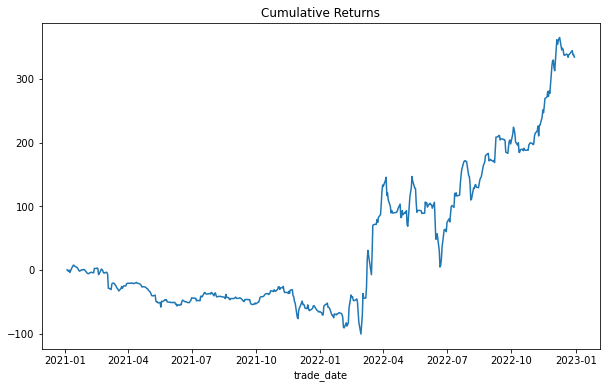

In [16]:
bt["cumulative_returns"].plot(title="Cumulative Returns", figsize=(10, 6))

In [17]:
####################
# final comparison with hierarchical model and global
####################

In [18]:

with open(f'preds_shared_cond3.pkl', 'rb') as file:
    pred_hier = pickle.load(file)[(0.001, 0.1)]

In [19]:
preds_global=pd.read_parquet('global_reg.parquet') 

In [20]:
preds_moe = preds_moe.rename(columns={"pred": "pred_moe"})
pred_hier = pred_hier.rename(columns={"pred": "pred_hier"})
pred_global = preds_global.rename(columns={"pred_alpha_0": "pred_global"})
preds_combined = preds_moe[["msgStamp", "trade_date", "pred_moe"]].merge(
    pred_hier[["msgStamp", "pred_hier"]],
    on="msgStamp",
    how="inner"
)
preds_combined = preds_combined.merge(
    pred_global[["msgStamp", "pred_global"]],
    on="msgStamp",
    how="inner"
)   
moe = (preds_combined["pred_moe"]/preds_combined["pred_moe"].std()).clip(-3,3)
hier = (preds_combined["pred_hier"]/preds_combined["pred_hier"].std()).clip(-3,3)
glo= (preds_combined["pred_global"]/preds_combined["pred_global"].std()).clip(-3,3)

preds_combined["pred_moe"] = moe
preds_combined["pred_hier"] = hier
preds_combined["pred_global"] = glo

preds_combined["pred_avg"] = (moe + hier) / 2

In [ ]:
import datetime
preds = preds_combined
signal_cols = [c for c in preds.columns if c.startswith("pred")]
bt_input = (
    preds.reset_index()
    .merge(df[["msgStamp", "ret_fopen"]], on="msgStamp", how="left")
)

end_date = datetime.date(2023, 1, 1)
bt_input = bt_input[(bt_input["trade_date"] <= end_date)].copy()
all_dates = pd.Index(sorted(bt_input["trade_date"].dropna().unique()), name="trade_date")


In [22]:
cum_pnl_df = pd.DataFrame(index=all_dates)
sharpe_rows = []

for col in signal_cols:
    bt = backtest(bt_input, feature_col=col, ret_col="ret_fopen")
    cum_pnl_df[col] = bt["cumulative_returns"].reindex(all_dates)
    sharpe_rows.append({"signal": col, "sharpe_ratio": bt["sharpe_ratio"], "return": bt["average_return"]})

sharpe_df = pd.DataFrame(sharpe_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)


In [23]:
sharpe_df

,signal,sharpe_ratio,return
0,pred_avg,1.320745,0.001360
1,pred_moe,1.178757,0.001497
2,pred_hier,1.165453,0.001134
3,pred_global,0.422698,0.000440


In [24]:
preds.corr()

,pred_moe,pred_hier,pred_global,pred_avg
pred_moe,1.000000,0.407981,0.431299,0.831607
pred_hier,0.407981,1.000000,0.594457,0.846322
pred_global,0.431299,0.594457,1.000000,0.613239
pred_avg,0.831607,0.846322,0.613239,1.000000


Text(0, 0.5, 'Cumulative PnL')

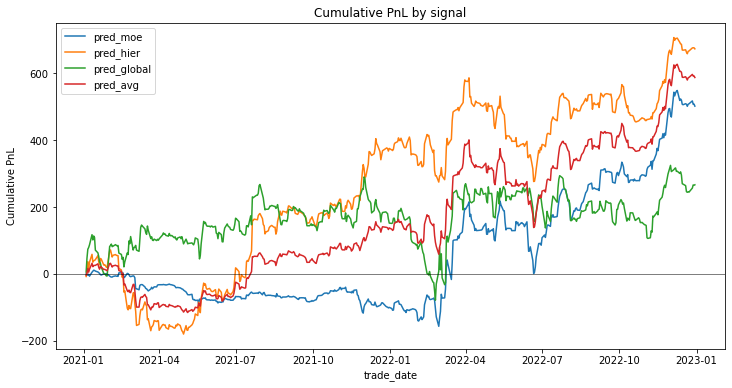

In [25]:
ax = cum_pnl_df.plot(figsize=(12, 6), title="Cumulative PnL by signal")
ax.axhline(0, color="black", linewidth=1, alpha=0.5)
ax.set_ylabel("Cumulative PnL")

In [ ]:
import datetime
preds = preds_combined
signal_cols = [c for c in preds.columns if c.startswith("pred")]
bt_input = (
    preds.reset_index()
    .merge(df[["msgStamp", "ret_fopen"]], on="msgStamp", how="left")
)

start_date = datetime.date(2023, 1, 1)
end_date = datetime.date(2025, 1, 1)
bt_input = bt_input[(bt_input["trade_date"] >= start_date) & (bt_input["trade_date"] <= end_date)].copy()
all_dates = pd.Index(sorted(bt_input["trade_date"].dropna().unique()), name="trade_date")


In [ ]:
cum_pnl_df = pd.DataFrame(index=all_dates)
sharpe_rows = []

for col in signal_cols:
    bt = backtest(bt_input, feature_col=col, ret_col="ret_fopen")
    cum_pnl_df[col] = bt["cumulative_returns"].reindex(all_dates)
    sharpe_rows.append({"signal": col, "sharpe_ratio": bt["sharpe_ratio"]})

sharpe_df = pd.DataFrame(sharpe_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)


In [119]:
sharpe_df

,signal,sharpe_ratio
0,pred_avg,1.566444
1,pred_hier,1.414668
2,pred_moe,1.306407
3,pred_global,0.130522


In [120]:
preds.corr()

,pred_moe,pred_hier,pred_global,pred_avg
pred_moe,1.000000,0.407981,0.431299,0.831607
pred_hier,0.407981,1.000000,0.594457,0.846322
pred_global,0.431299,0.594457,1.000000,0.613239
pred_avg,0.831607,0.846322,0.613239,1.000000


Text(0, 0.5, 'Cumulative PnL')

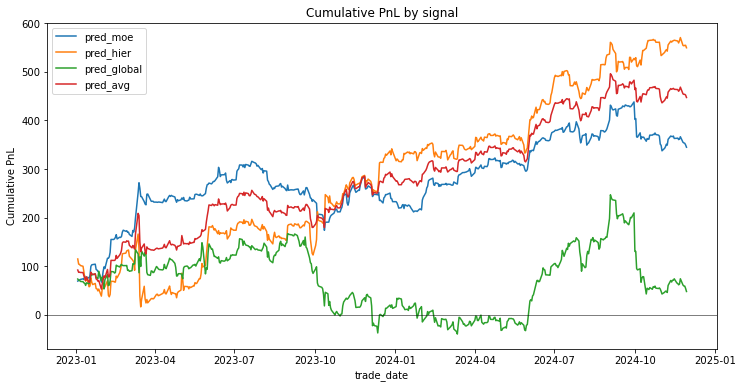

In [121]:
ax = cum_pnl_df.plot(figsize=(12, 6), title="Cumulative PnL by signal")
ax.axhline(0, color="black", linewidth=1, alpha=0.5)
ax.set_ylabel("Cumulative PnL")